#Name: OBAJE PAUL
###Colab Link: https://colab.research.google.com/drive/1rgw_RNv3hjTUhf39vhTj06UAeRzK7E-S?usp=sharing

###Github Repository Link:


In [1]:
!jupyter nbconvert --to html "/content/Assignment11.ipynb"

[NbConvertApp] Converting notebook /content/Assignment11.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 2119959 bytes to /content/Assignment11.html


In [ ]:
# Assignment 11: Image Classification Using Random Forest

# TODO: Import the required libraries

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# TODO: Upload the image dataset

from google.colab import files

uploaded = files.upload()

print("Dataset ZIP uploaded successfully.")

Saving images.zip to images.zip
Dataset ZIP uploaded successfully.


In [ ]:
# TODO: Extract the image dataset

zip_file = 'images.zip'
extract_path = '/content/image_dataset'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Dataset location:", extract_path)

Dataset extracted successfully.
Dataset location: /content/image_dataset


In [ ]:
# TODO: Check the dataset structure and identify the image folder

# The ZIP contains an "images" folder
extract_path = '/content/image_dataset/images'

print("Folders inside the image dataset:")

for item in os.listdir(extract_path):
    item_path = os.path.join(extract_path, item)

    if os.path.isdir(item_path):
        print("-", item)

Folders inside the image dataset:
- pizza
- dalmatian
- dollar_bill
- sunflower
- soccer_ball


In [ ]:
# TODO: Count the number of images in each class

class_counts = {}

for class_name in os.listdir(extract_path):
    class_path = os.path.join(extract_path, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        class_counts[class_name] = image_count

print("Number of images in each class:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal images:", sum(class_counts.values()))

Number of images in each class:
pizza: 52
dalmatian: 67
dollar_bill: 51
sunflower: 85
soccer_ball: 54

Total images: 309


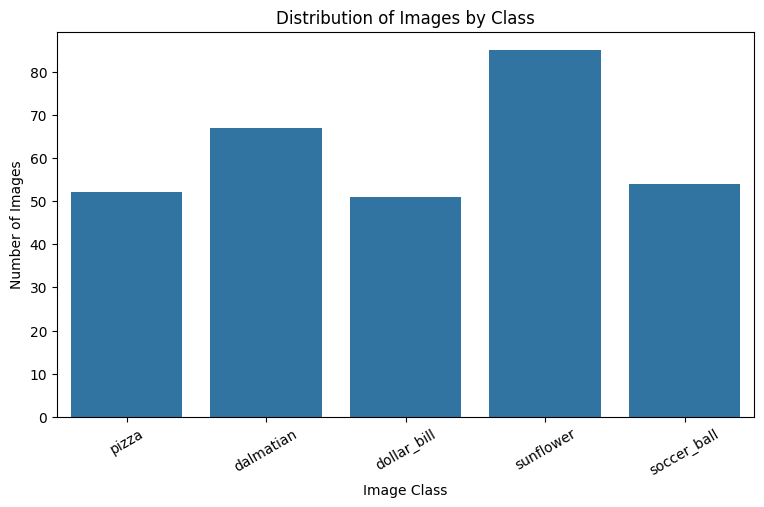

In [ ]:
# TODO: Visualize the distribution of image classes

plt.figure(figsize=(9, 5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title('Distribution of Images by Class')
plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)

plt.show()

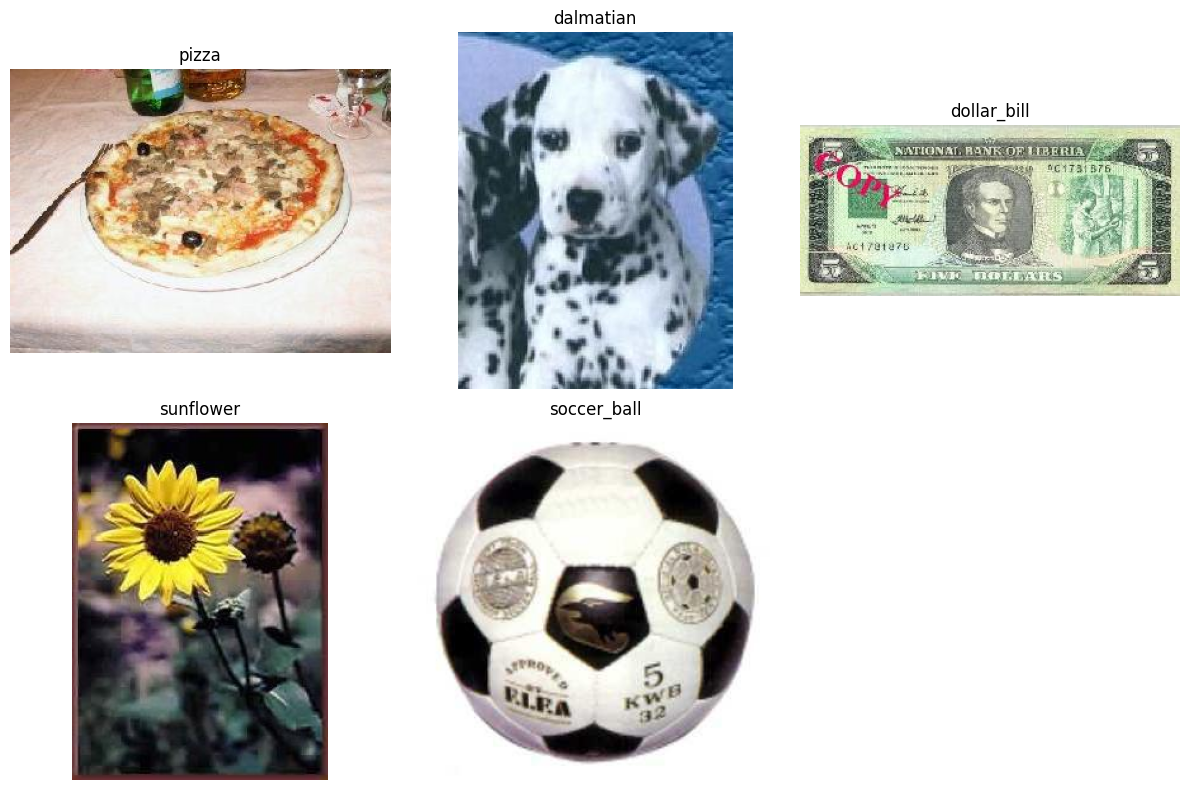

In [ ]:
# TODO: Display sample images from the dataset

plt.figure(figsize=(12, 8))

classes = list(class_counts.keys())

for i, class_name in enumerate(classes):
    class_path = os.path.join(extract_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Set the image size and class labels

IMG_SIZE = (64, 64)

class_names = sorted(class_counts.keys())

print("Image size:", IMG_SIZE)
print("Classes:", class_names)

Image size: (64, 64)
Classes: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


In [ ]:
# TODO: Load, resize, normalize, and flatten the images

images = []
labels = []

for class_name in class_names:
    class_path = os.path.join(extract_path, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):

            image_path = os.path.join(class_path, file_name)

            try:
                image = Image.open(image_path).convert('RGB')
                image = image.resize(IMG_SIZE)

                image_array = np.array(image, dtype=np.float32)

                # Normalize pixel values to the range 0 to 1
                image_array = image_array / 255.0

                # Flatten the image into one feature vector
                image_array = image_array.flatten()

                images.append(image_array)
                labels.append(class_name)

            except Exception as e:
                print("Could not process:", image_path)
                print("Error:", e)

X = np.array(images)
y = np.array(labels)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

Images shape: (309, 12288)
Labels shape: (309,)


In [ ]:
# TODO: Check the processed image data

print("Number of images:", len(X))
print("Number of features per image:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

print("\nClasses:")
print(np.unique(y))

print("\nPixel value range:")
print("Minimum:", X.min())
print("Maximum:", X.max())

Number of images: 309
Number of features per image: 12288
Number of classes: 5

Classes:
['dalmatian' 'dollar_bill' 'pizza' 'soccer_ball' 'sunflower']

Pixel value range:
Minimum: 0.0
Maximum: 1.0


In [ ]:
# TODO: Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data shape: (247, 12288)
Testing data shape: (62, 12288)
Training labels: (247,)
Testing labels: (62,)


In [ ]:
# TODO: Define the parameter grid for GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("Parameter grid:")
print(param_grid)

Parameter grid:
{'n_estimators': [50, 100], 'max_depth': [None, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [ ]:
# TODO: Create the Random Forest Classifier

rf_classifier = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

print("Random Forest classifier created successfully.")

Random Forest classifier created successfully.


In [ ]:
# TODO: Perform GridSearchCV to find the best Random Forest parameters

grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nGrid search completed successfully.")
print("Best parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Grid search completed successfully.
Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
# TODO: Get the best Random Forest model

best_rf_model = grid_search.best_estimator_

print("Best Random Forest model:")
print(best_rf_model)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

Best Random Forest model:
RandomForestClassifier(min_samples_split=5, n_jobs=-1, random_state=42)

Best cross-validation accuracy:
0.7772553629150748


In [ ]:
# TODO: Train the best Random Forest model

best_rf_model.fit(X_train, y_train)

print("Best Random Forest model trained successfully.")

Best Random Forest model trained successfully.


In [ ]:
# TODO: Make predictions on the test set

y_pred_rf = best_rf_model.predict(X_test)

print("Random Forest predictions completed.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions completed.
Number of predictions: 62


In [ ]:
# TODO: Evaluate the Random Forest model

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

print("Random Forest Evaluation")
print("------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

Random Forest Evaluation
------------------------
Accuracy : 0.7580645161290323
Precision: 0.7571586119973218
Recall   : 0.7580645161290323
F1-score : 0.753257247060303


In [ ]:
# TODO: Create the classification report

print("Random Forest Classification Report:")
print()

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

   dalmatian       0.77      0.71      0.74        14
 dollar_bill       0.80      0.80      0.80        10
       pizza       0.67      0.60      0.63        10
 soccer_ball       0.78      0.64      0.70        11
   sunflower       0.76      0.94      0.84        17

    accuracy                           0.76        62
   macro avg       0.76      0.74      0.74        62
weighted avg       0.76      0.76      0.75        62



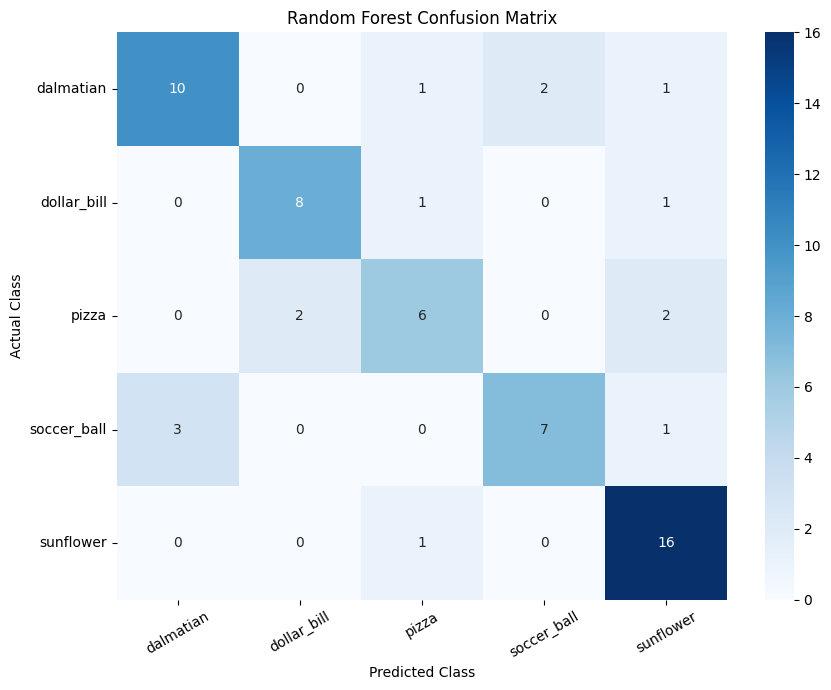

In [ ]:
# TODO: Create and visualize the confusion matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=class_names
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Get feature importances from the best Random Forest model

feature_importances = best_rf_model.feature_importances_

print("Number of feature importances:", len(feature_importances))
print("Total importance:", feature_importances.sum())

Number of feature importances: 12288
Total importance: 1.0


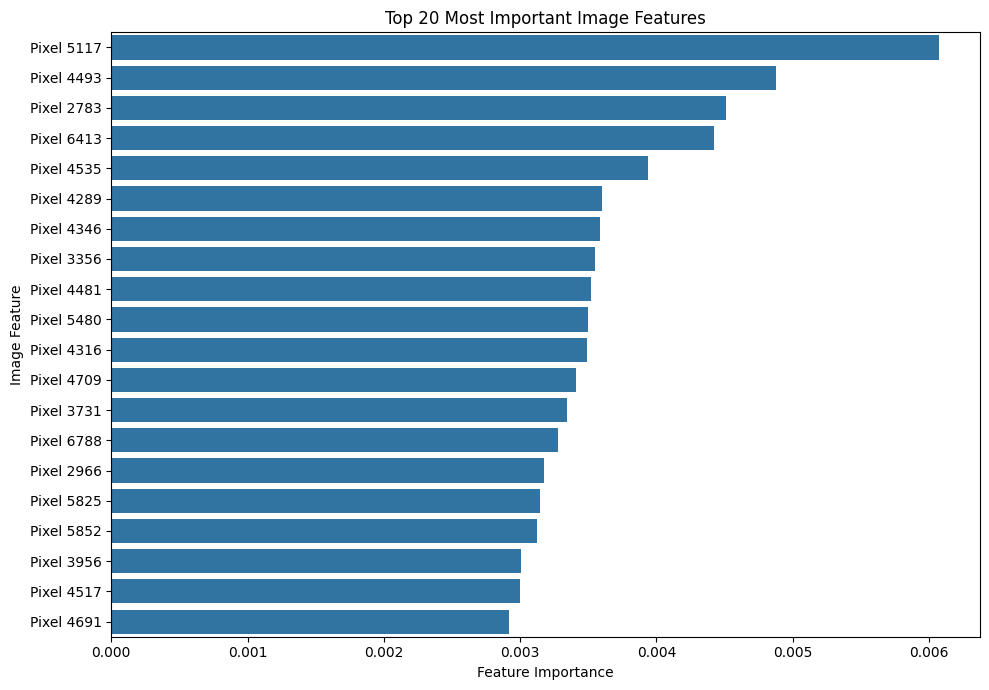

In [ ]:
# TODO: Create a bar plot of the most important features

top_n = 20

importance_indices = np.argsort(feature_importances)[-top_n:][::-1]

top_importances = feature_importances[importance_indices]

top_feature_names = [
    f'Pixel {index}'
    for index in importance_indices
]

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_importances,
    y=top_feature_names
)

plt.title('Top 20 Most Important Image Features')
plt.xlabel('Feature Importance')
plt.ylabel('Image Feature')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Create a function to predict the class of a new image

def predict_image(image_path):

    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Resize the image
    image = image.resize(IMG_SIZE)

    # Convert image to a numerical array
    image_array = np.array(image, dtype=np.float32)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Flatten the image
    image_array = image_array.flatten()

    # Reshape for the model
    image_array = image_array.reshape(1, -1)

    # Predict the class
    prediction = best_rf_model.predict(image_array)

    return prediction[0]

In [ ]:
# TODO: Upload a new image for prediction

from google.colab import files

uploaded_new_image = files.upload()

new_image_path = list(uploaded_new_image.keys())[0]

print("New image uploaded:", new_image_path)

Saving new pizza.jfif to new pizza.jfif
New image uploaded: new pizza.jfif


In [ ]:
# TODO: Predict the class of the new image

predicted_class = predict_image(new_image_path)

print("New Image:", new_image_path)
print("Predicted Class:", predicted_class)

New Image: new pizza.jfif
Predicted Class: pizza


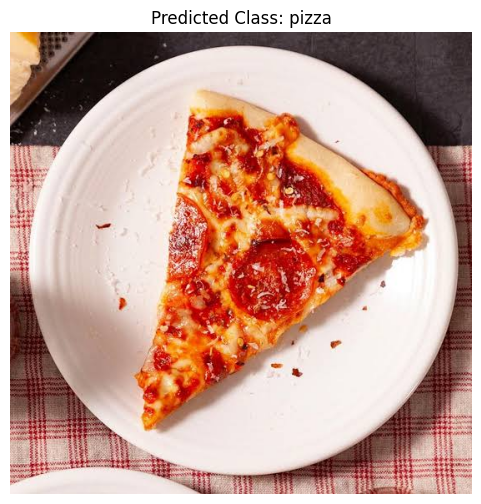

In [ ]:
# Display the new image and its prediction

image = Image.open(new_image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f'Predicted Class: {predicted_class}')
plt.axis('off')
plt.show()

In [ ]:
# BONUS: Import SVM classifier

from sklearn.svm import SVC

print("SVM imported successfully.")

SVM imported successfully.


In [ ]:
# BONUS: Create and train the SVM model

svm_param_grid = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf']
}

svm_classifier = SVC()

svm_grid_search = GridSearchCV(
    estimator=svm_classifier,
    param_grid=svm_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print("\nSVM Grid Search completed.")
print("Best SVM parameters:")
print(svm_grid_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits

SVM Grid Search completed.
Best SVM parameters:
{'C': 10, 'kernel': 'rbf'}


In [ ]:
# BONUS: Evaluate the SVM model

best_svm_model = svm_grid_search.best_estimator_

y_pred_svm = best_svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average='weighted',
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average='weighted',
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average='weighted',
    zero_division=0
)

print("SVM Evaluation")
print("--------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1-score :", svm_f1)

SVM Evaluation
--------------
Accuracy : 0.8064516129032258
Precision: 0.8164442141521938
Recall   : 0.8064516129032258
F1-score : 0.8056970382946613


In [ ]:
# BONUS: Compare Random Forest and SVM

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [rf_accuracy, svm_accuracy],
    'Precision': [rf_precision, svm_precision],
    'Recall': [rf_recall, svm_recall],
    'F1-Score': [rf_f1, svm_f1]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.758065   0.757159  0.758065  0.753257
1            SVM  0.806452   0.816444  0.806452  0.805697


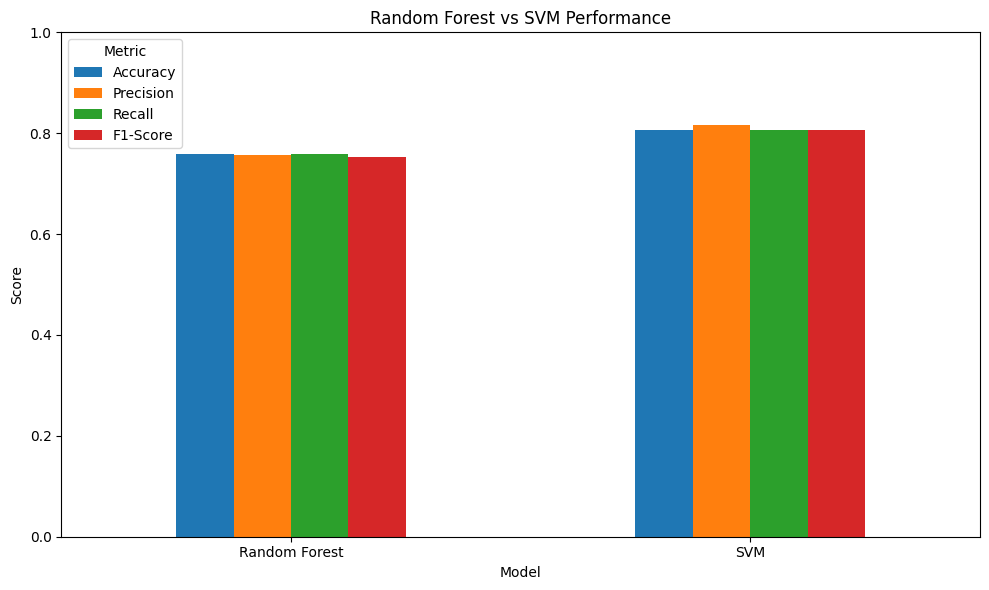

In [ ]:
# BONUS: Visualize Random Forest and SVM performance

comparison_plot = comparison.set_index('Model')

comparison_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Random Forest vs SVM Performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title='Metric')

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Display the final project summary

print("ASSIGNMENT 11: IMAGE CLASSIFICATION USING RANDOM FOREST")
print("=" * 55)

print("\nDataset")
print("-------")
print("Total images:", len(X))
print("Number of classes:", len(class_names))
print("Classes:", class_names)
print("Image size:", IMG_SIZE)

print("\nRandom Forest")
print("-------------")
print("Best parameters:", grid_search.best_params_)
print("Cross-validation accuracy:", grid_search.best_score_)
print("Test accuracy:", rf_accuracy)
print("Test precision:", rf_precision)
print("Test recall:", rf_recall)
print("Test F1-score:", rf_f1)

print("\nNew Image Prediction")
print("--------------------")
print("Predicted class:", predicted_class)

print("\nAssignment completed successfully.")

ASSIGNMENT 11: IMAGE CLASSIFICATION USING RANDOM FOREST

Dataset
-------
Total images: 309
Number of classes: 5
Classes: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']
Image size: (64, 64)

Random Forest
-------------
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Cross-validation accuracy: 0.7772553629150748
Test accuracy: 0.7580645161290323
Test precision: 0.7571586119973218
Test recall: 0.7580645161290323
Test F1-score: 0.753257247060303

New Image Prediction
--------------------
Predicted class: pizza

Assignment completed successfully.
